<a href="https://colab.research.google.com/github/Lakshita672/Fake-News/blob/main/FaceMaskDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing Face Mask Dataset

In [ ]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 95% 155M/163M [00:00<00:00, 1.62GB/s]
100% 163M/163M [00:00<00:00, 1.49GB/s]


In [ ]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


**Importing the Dependencies**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2634.jpg', 'with_mask_3522.jpg', 'with_mask_3491.jpg', 'with_mask_2850.jpg', 'with_mask_2453.jpg']
['with_mask_773.jpg', 'with_mask_1528.jpg', 'with_mask_951.jpg', 'with_mask_964.jpg', 'with_mask_2548.jpg']


In [ ]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2733.jpg', 'without_mask_3069.jpg', 'without_mask_2257.jpg', 'without_mask_652.jpg', 'without_mask_3739.jpg']
['without_mask_20.jpg', 'without_mask_3754.jpg', 'without_mask_858.jpg', 'without_mask_3622.jpg', 'without_mask_773.jpg']


In [ ]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [ ]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [ ]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [ ]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

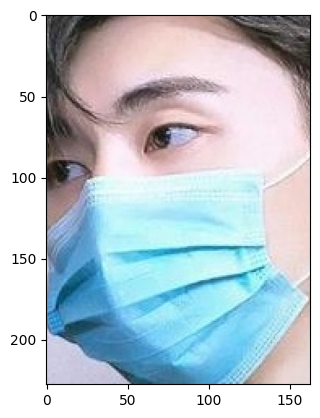

In [ ]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

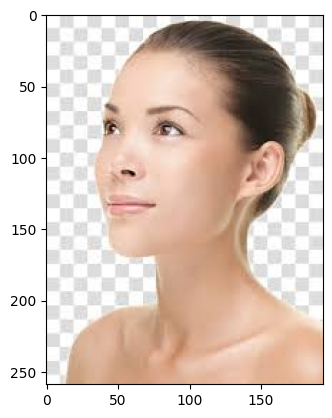

In [ ]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [ ]:
IMG_SIZE = 128

data = []
labels = []

with_mask_path = '/content/data/with_mask/'
without_mask_path = '/content/data/without_mask/'

for img_file in os.listdir(with_mask_path):
    image = Image.open(with_mask_path + img_file).convert('RGB')
    image = image.resize((IMG_SIZE, IMG_SIZE))
    data.append(np.array(image))
    labels.append(1)

for img_file in os.listdir(without_mask_path):
    image = Image.open(without_mask_path + img_file).convert('RGB')
    image = image.resize((IMG_SIZE, IMG_SIZE))
    data.append(np.array(image))
    labels.append(0)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[206, 197, 180],
        [206, 197, 180],
        [207, 198, 181],
        ...,
        [214, 215, 206],
        [223, 224, 218],
        [ 90,  90,  87]],

       [[206, 197, 180],
        [206, 197, 180],
        [207, 198, 181],
        ...,
        [213, 213, 204],
        [223, 224, 218],
        [ 90,  90,  87]],

       [[206, 197, 180],
        [206, 197, 180],
        [207, 198, 181],
        ...,
        [211, 211, 202],
        [223, 224, 218],
        [ 90,  90,  87]],

       ...,

       [[197, 186, 190],
        [197, 186, 190],
        [196, 185, 189],
        ...,
        [231, 213, 196],
        [238, 226, 214],
        [103,  93,  86]],

       [[210, 199, 203],
        [209, 198, 202],
        [207, 196, 200],
        ...,
        [232, 212, 195],
        [239, 224, 213],
        [103,  93,  85]],

       [[211, 202, 205],
        [210, 201, 204],
        [207, 198, 201],
        ...,
        [231, 206, 187],
        [241, 220, 204],
        [104,  87,  78]]], dtype=uint8)
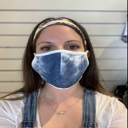

In [ ]:
data[0]

In [ ]:
type(data[0])

numpy.ndarray

In [ ]:
data[0].shape

(128, 128, 3)

In [ ]:
X = np.array(data, dtype='float32')
Y = np.array(labels)

# Normalize ONCE
X = X / 255.0


In [ ]:
type(X)

numpy.ndarray

In [ ]:
type(Y)

numpy.ndarray

In [ ]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [ ]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)


In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [ ]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [ ]:
X_train[0]

array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       ...,

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]], dtype=float32)

In [ ]:
X_train_scaled[0]

array([[[0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        ...,
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157]],

       [[0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        ...,
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157]],

       [[0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        ...,
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157]],

       ...,

       [[0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0

**Building a Convolutional Neural Networks (CNN)**

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')   # ✅ SINGLE NEURON
])


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',     # ✅ FIXED
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train,
    Y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)


Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.8159 - loss: 0.4691 - val_accuracy: 0.5025 - val_loss: 1.6140
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9299 - loss: 0.1868 - val_accuracy: 0.7620 - val_loss: 0.6153
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9527 - loss: 0.1264 - val_accuracy: 0.9091 - val_loss: 0.2376
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9709 - loss: 0.0758 - val_accuracy: 0.9438 - val_loss: 0.1591
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9807 - loss: 0.0591 - val_accuracy: 0.9488 - val_loss: 0.1609
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9845 - loss: 0.0518 - val_accuracy: 0.9438 - val_loss: 0.1684
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9871 - loss: 0.0357 - val_accuracy: 0.9355 - val_loss: 0.1915
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9874 - loss: 0.0350 - val_acc

**Model Evaluation**

In [ ]:
loss, accuracy = model.evaluate(X_test, Y_test)
print("Test Accuracy:", accuracy)


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9368 - loss: 0.2287
Test Accuracy: 0.9410986304283142


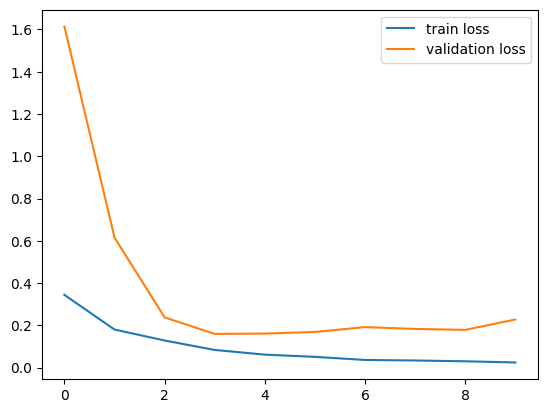

KeyError: 'acc'

In [ ]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def predict_mask_face_only(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) == 0:
        return "No face detected", None

    # Take the largest face (main subject)
    faces = sorted(faces, key=lambda x: x[2]*x[3], reverse=True)
    x, y, w, h = faces[0]

    face = img[y:y+h, x:x+w]
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = cv2.resize(face, (128,128))
    face = face / 255.0
    face = np.expand_dims(face, axis=0)

    prediction = model.predict(face)[0][0]

    if prediction > 0.5:
        return "The person is wearing a mask", prediction
    else:
        return "The person is not wearing a mask", prediction


In [ ]:
# def predict_mask(image_path):
#     image = cv2.imread(image_path)
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # ✅ FIX
#     image = cv2.resize(image, (128,128))
#     image = image / 255.0
#     image = np.expand_dims(image, axis=0)

#     prediction = model.predict(image)[0][0]

#     if prediction > 0.5:
#         return "The person is wearing a mask", prediction
#     else:
#         return "The person is not wearing a mask", prediction


In [ ]:
result, confidence = predict_mask('/content/test.jpg')
print(result)
print("Confidence:", confidence)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
The person is wearing a mask
Confidence: 0.96474427


Path of the image to be predicted: /content/test3.jpg


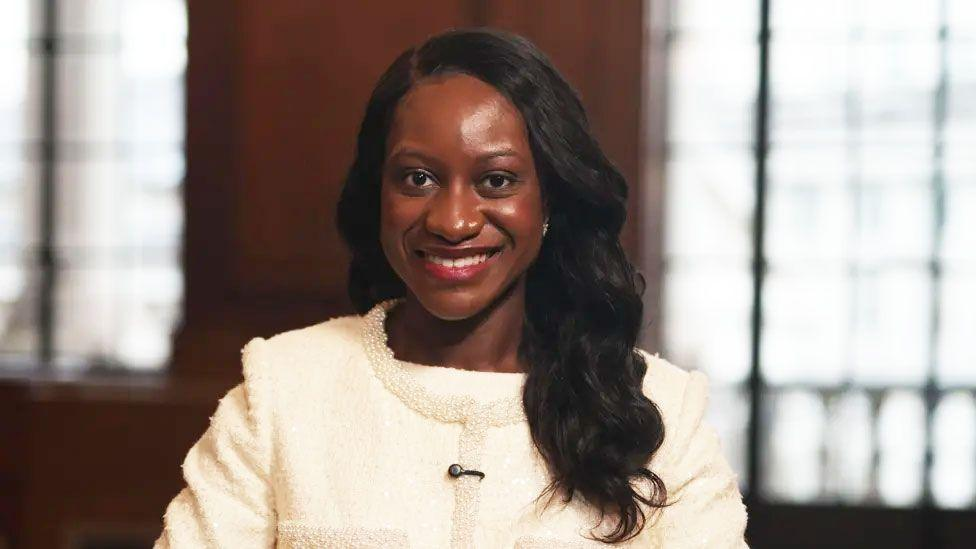

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[0.99994767]]
0
The person in the image is not wearing a mask


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')